In [7]:
import pandas as pd

#is the shared start of the three web addresses, so we don't repeat it.
base = "https://huggingface.co/datasets/masakhane/masakhaner2/resolve/refs%2Fconvert%2Fparquet/twi"

train_df = pd.read_parquet(f"{base}/train/0000.parquet")
val_df   = pd.read_parquet(f"{base}/validation/0000.parquet")
test_df  = pd.read_parquet(f"{base}/test/0000.parquet")

print(len(train_df), len(val_df), len(test_df))
train_df.head()


4240 605 1211


,id,tokens,ner_tags
0,0,"[Mmom, obi, a, ɔwɔ, ahobrɛase, no, fi, ne, kom...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,"[Dr, ., Nikhil, Sharma, a, ɔfiri, Himachal, Pr...","[0, 0, 1, 2, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"[Nsu, a, ɛtɔ, denneennen, no, aka, nnipa, pii,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 5, 0, 5, 0, ..."
3,3,"[Owura, Asante, Bediatuo, sii, so, dua, biom, ...","[0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[Sɛ, yɛwɔ, tema, ma, obi, a, ,, yebehu, sɛ, ɛn...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [8]:
# Tool that counts how often each item appears
from collections import Counter

# Put all words from all training sentences into one list
train_tokens = [word for sentence in train_df["tokens"] for word in sentence]

# Count how many times each word appears
word_counts = Counter(train_tokens)

# Show total words, distinct words, and words seen only once
print("Total tokens:", len(train_tokens))
print("Vocabulary size (types):", len(word_counts))
print("Words seen only once:", sum(1 for w, c in word_counts.items() if c == 1))
print()

# Show the 20 most common words
print("20 most common words:")
print(word_counts.most_common(20))


Total tokens: 112160
Vocabulary size (types): 11610
Words seen only once: 6305

20 most common words:
[('no', 6823), ('a', 5663), ('sɛ', 4312), (',', 4020), ('.', 3678), ('na', 2231), ('mu', 2217), ('ne', 2109), ('wɔn', 1793), ('wɔ', 1777), ('so', 1430), ('ho', 1317), ('yi', 1133), ('de', 869), ('bi', 737), ('saa', 628), ('nso', 559), ('yɛ', 533), ('adwuma', 506), ('hɔ', 476)]


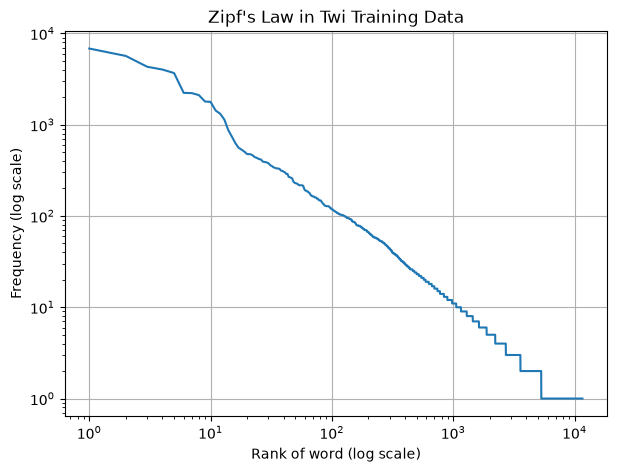

In [9]:
# Tool for drawing charts
import matplotlib.pyplot as plt

# Word frequencies sorted from most to least common
frequencies = [count for word, count in word_counts.most_common()]

# Ranks: 1 for the most common word, 2 for the next, and so on
ranks = range(1, len(frequencies) + 1)

# Plot rank against frequency on log-log axes
plt.figure(figsize=(7, 5))
plt.loglog(ranks, frequencies)
plt.xlabel("Rank of word (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law in Twi Training Data")
plt.grid(True)
plt.show()


In [10]:
# Test Zipf: if rank and frequency are inversely proportional, rank × frequency stays roughly constant
for rank in [1, 2, 5, 10, 50, 100, 500, 1000, 5000]:
    word, freq = word_counts.most_common()[rank - 1]
    print(f"Rank {rank:>5} | {word:>12} | freq {freq:>5} | rank × freq = {rank * freq}")


Rank     1 |           no | freq  6823 | rank × freq = 6823
Rank     2 |            a | freq  5663 | rank × freq = 11326
Rank     5 |            . | freq  3678 | rank × freq = 18390
Rank    10 |           wɔ | freq  1777 | rank × freq = 17770
Rank    50 |           ka | freq   229 | rank × freq = 11450
Rank   100 |           Dr | freq   118 | rank × freq = 11800
Rank   500 |      wɔatumi | freq    23 | rank × freq = 11500
Rank  1000 |      atuateɛ | freq    11 | rank × freq = 11000
Rank  5000 |          End | freq     2 | rank × freq = 10000


In [11]:
# Lowercase every word and add start/end markers to each sentence
def preprocess(sentences):
    cleaned = []
    for sentence in sentences:
        words = [word.lower() for word in sentence]
        cleaned.append(["<s>"] + words + ["</s>"])
    return cleaned

# Apply the same cleaning to all three splits
train_sents = preprocess(train_df["tokens"])
val_sents   = preprocess(val_df["tokens"])
test_sents  = preprocess(test_df["tokens"])

# Compare a sentence before and after cleaning
print("Before:", list(train_df["tokens"][0]))
print("After: ", train_sents[0])


Before: ['Mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', ',', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', 'obesua', 'biribi', 'afi', 'wɔn', 'hɔ', '.']
After:  ['<s>', 'mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', ',', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', 'obesua', 'biribi', 'afi', 'wɔn', 'hɔ', '.', '</s>']


In [12]:
# Count words in the cleaned training data
train_counts = Counter(word for sentence in train_sents for word in sentence)

# Vocabulary = words seen at least 2 times in training
vocab = {word for word, count in train_counts.items() if count >= 2}

# Replace any word not in the vocabulary with <UNK>
def replace_unk(sentences, vocab):
    return [[word if word in vocab else "<UNK>" for word in sentence] for sentence in sentences]

# Apply to all three splits, always using the TRAINING vocabulary
train_sents = replace_unk(train_sents, vocab)
val_sents   = replace_unk(val_sents, vocab)
test_sents  = replace_unk(test_sents, vocab)

# Check the results
print("Vocabulary size (incl. <UNK>):", len(vocab) + 1)
test_words = [word for sentence in test_sents for word in sentence]
print("Share of test words that are <UNK>:", round(test_words.count("<UNK>") / len(test_words) * 100, 1), "%")
print("Example:", train_sents[0])


Vocabulary size (incl. <UNK>): 4992
Share of test words that are <UNK>: 8.9 %
Example: ['<s>', 'mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', ',', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', '<UNK>', 'biribi', 'afi', 'wɔn', 'hɔ', '.', '</s>']
